# TP4 — Réseaux Convolutionnels : Optimisation et Régularisation (PyTorch)
## Solutions complètes

> **Environnement :** Google Colab avec GPU (ou machine locale avec CUDA).  
> Exécuter toutes les cellules dans l'ordre.


## Partie 1 – Introduction aux réseaux convolutionnels

### 1.4 Questions théoriques

---

**Q1. Taille de sortie, nombre de poids (convolution simple)**

Pour une entrée *x × y × z*, un filtre de padding *p*, stride *s*, kernel *k* :

$$n'_x = \lfloor (x + 2p - k)/s \rfloor + 1, \quad n'_y = \lfloor (y + 2p - k)/s \rfloor + 1$$

**Sortie :** $n'_x \times n'_y \times 1$ (pour 1 filtre).

**Poids à apprendre (1 filtre) :** $k \times k \times z + 1$ (bias inclus).

**Poids pour une couche FC de même sortie :** $(x \cdot y \cdot z) \times (n'_x \cdot n'_y)$ — exponentiellement plus grand.

---

**Q2. Avantages de la convolution vs FC**

| | Convolution | FC |
|---|---|---|
| Partage des poids | ✅ Le même filtre est appliqué partout | ❌ Poids distincts par position |
| Invariance spatiale | ✅ Détecte un motif quelle que soit sa position | ❌ |
| Nombre de paramètres | Très réduit (k×k×z pour 1 filtre) | Quadratique en la taille de l'entrée |
| **Limite principale** | Hypothèse de **stationnarité** (le motif détecté est le même partout) | — |

La convolution suppose que les caractéristiques utiles sont *locales et répétées*.  
Elle ne capture pas facilement les dépendances à longue portée (d'où les architectures Transformer).

---

**Q3. Intérêt du pooling spatial**

- **Réduction de dimension** → moins de calculs et de paramètres dans les couches suivantes.  
- **Invariance locale aux translations** : une légère déformation de l'objet ne change pas la réponse.  
- **Augmentation du champ récepteur** des neurones des couches suivantes.  
- Réduit le risque de sur-apprentissage.

---

**Q4 ★. Réseau convolutionnel sur image plus grande (224×224 → plus grand)**

Oui, **toutes les couches de convolution et de pooling** peuvent être calculées sans modification  
car leurs opérations sont définies localement (fenêtre glissante). La sortie sera *plus grande*  
spatialement.  
En revanche, les couches **fully-connected** ont un nombre fixe d'entrées → elles ne peuvent  
*pas* être appliquées directement sur une entrée de taille différente.

---

**Q5. FC comme cas particulier de convolution**

Une couche FC de *m* neurones prenant un tenseur *1 × 1 × C* en entrée est équivalente à  
*m* convolutions de taille *1×1*. Plus généralement, une FC prenant un tenseur *h × w × C*  
est équivalente à une convolution *h × w* (kernel = toute la feature map), produisant une  
sortie *1 × 1 × m*.

---

**Q6. FC remplacées par des convolutions → entrée plus grande**

Si les FC sont remplacées par leurs convolutions équivalentes, on peut appliquer le réseau  
entier à n'importe quelle entrée. La sortie est alors **spatialement étendue** :  
pour une entrée I fois plus grande, la sortie est une grille de taille proportionnelle  
où chaque cellule correspond à la classification d'une fenêtre de l'image originale.  
→ Utile pour la **détection d'objets** (sliding-window dense, beaucoup plus efficace).

---

**Q7. Champ récepteur (receptive field)**

- **Couche conv 1** (kernel 5×5) : chaque neurone dépend d'une région **5×5** de l'image.  
- **Couche conv 2** (kernel 5×5, après pool 2×2) : une position dans la feature map 2  
  correspond à une région 2×5=10 → et le filtre 5×5 sur cette sortie couvre **10+4=14 × 14** pixels d'entrée  
  (formule exacte : RF_k = RF_{k-1} + (kernel-1) × stride_produit).  
- **Couches profondes** : le champ récepteur continue de croître, pouvant couvrir  
  une grande fraction ou la totalité de l'image.  
- **Interprétation** : les neurones des premières couches détectent des motifs *locaux*  
  (bords, coins) ; les neurones profonds intègrent des contextes *globaux* (formes d'objets,  
  scènes entières).

---

**Q8. Padding et stride pour conserver la taille spatiale (conv)**

On veut sortie = entrée : $n'_x = x \Rightarrow p = (k-1)/2$, $s=1$.  
Pour k=5 : **padding = 2**, **stride = 1**.

---

**Q9. Padding et stride pour réduire d'un facteur 2 (max pooling)**

On veut $n'_x = x/2$ : **kernel=2**, **stride=2**, **padding=0**.

---

**Q10. Tailles et poids par couche (architecture AlexNet-CIFAR)**

| Couche | Sortie | Poids |
|---|---|---|
| Input | 32×32×3 | 0 |
| conv1 : 32 filtres 5×5, p=2, s=1 | 32×32×32 | (5×5×3+1)×32 = **2 432** |
| pool1 : 2×2 s=2 | 16×16×32 | 0 |
| conv2 : 64 filtres 5×5, p=2, s=1 | 16×16×64 | (5×5×32+1)×64 = **51 264** |
| pool2 : 2×2 s=2 | 8×8×64 | 0 |
| conv3 : 64 filtres 5×5, p=2, s=1 | 8×8×64 | (5×5×64+1)×64 = **102 464** |
| pool3 : 2×2 s=2 | 4×4×64 = 1 024 vecteur | 0 |
| fc4 : 1000 neurones | 1 000 | 1024×1000+1000 = **1 025 000** |
| fc5 : 10 neurones | 10 | 1000×10+10 = **10 010** |

→ La couche **fc4 domine largement** (~87 % des paramètres).

---

**Q11. Nombre total de paramètres : ~1 191 170**

Dataset CIFAR-10 train : 50 000 exemples.  
Ratio paramètres/exemples ≈ 24 → le réseau a beaucoup de paramètres par exemple  
d'entraînement → risque élevé de sur-apprentissage, justifiant la régularisation.

---

**Q12. Comparaison avec BoW + SVM**

Un BoW+SVM classique a typiquement un dictionnaire de ~1000–4096 descripteurs  
et un vecteur de features de cette dimension → quelques dizaines de milliers de poids au maximum.  
Le CNN a **~24× plus** de paramètres mais apprend des représentations hiérarchiques  
*bout-en-bout* bien plus puissantes.


## Partie 2 – Apprentissage *from scratch* sur CIFAR-10

In [1]:
# ---------- Installation / imports ----------
# !wget https://raw.githubusercontent.com/deep-learning-polytech/deep-learning-polytech.github.io/master/code/TP5-6/utils.py

import os, time
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PRINT_INTERVAL = 100
PATH = "datasets"
cuda = torch.cuda.is_available()
device = torch.device("cuda" if cuda else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
# ---------- Utilitaires ----------
class AverageMeter:
    def __init__(self): self.reset()
    def reset(self):    self.val = self.avg = self.sum = self.count = 0
    def update(self, val, n=1):
        self.val   = val
        self.sum  += val * n
        self.count += n
        self.avg   = self.sum / self.count

def accuracy(output, target, topk=(1,)):
    with torch.no_grad():
        maxk = max(topk)
        bs   = target.size(0)
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum()
            res.append(correct_k.mul_(100.0 / bs))
        return res
def plot_curves(train_loss, val_loss, train_acc, val_acc, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(train_loss, label='Train'); ax1.plot(val_loss, label='Val')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.set_title(title + ' – Loss')
    ax2.plot(train_acc,  label='Train'); ax2.plot(val_acc,  label='Val')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Top-1 Acc (%)'); ax2.legend(); ax2.set_title(title + ' – Accuracy')
    plt.tight_layout(); plt.show()


In [3]:
# ---------- Architecture AlexNet-CIFAR (Section 2.1) ----------
class AlexNetCIFAR(nn.Module):
    """
    Architecture proche d'AlexNet adaptée à CIFAR-10 (images 32×32).

    conv1: 32 filtres 5×5, padding=2, stride=1  → 32×32×32
    pool1: 2×2                                   → 16×16×32
    conv2: 64 filtres 5×5, padding=2, stride=1  → 16×16×64
    pool2: 2×2                                   →  8×8×64
    conv3: 64 filtres 5×5, padding=2, stride=1  →  8×8×64
    pool3: 2×2                                   →  4×4×64
    fc4:  1000 (+ ReLU)
    fc5:  10   (softmax inclus dans la CrossEntropy)
    """
    def __init__(self, dropout_p=0.0, use_bn=False):
        super().__init__()
        def conv_block(in_c, out_c, use_bn=use_bn):
            layers = [nn.Conv2d(in_c, out_c, 5, stride=1, padding=2, bias=not use_bn)]
            if use_bn: layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            return layers

        self.features = nn.Sequential(
            *conv_block(3,  32),  nn.MaxPool2d(2, 2),
            *conv_block(32, 64),  nn.MaxPool2d(2, 2),
            *conv_block(64, 64),  nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(4*4*64, 1000),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(1000, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# Vérification rapide
_m = AlexNetCIFAR()
_x = torch.zeros(2, 3, 32, 32)
print("Output shape:", _m(_x).shape)
print("Nb paramètres:", sum(p.numel() for p in _m.parameters()))


Output shape: torch.Size([2, 10])
Nb paramètres: 1191170


In [4]:
# ---------- Boucle d'entraînement / évaluation ----------
def run_epoch(loader, model, criterion, optimizer=None):
    model.train() if optimizer else model.eval()
    meter_loss = AverageMeter()
    meter_top1 = AverageMeter()
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        if optimizer:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        prec1, = accuracy(outputs, targets, topk=(1,))
        meter_loss.update(loss.item(),   inputs.size(0))
        meter_top1.update(prec1.item(),  inputs.size(0))
    return meter_top1.avg, meter_loss.avg


def train(model, train_loader, val_loader, lr=0.01, epochs=30,
          optimizer_fn=None, scheduler_fn=None, label=""):
    criterion = nn.CrossEntropyLoss().to(device)
    if optimizer_fn is None:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    else:
        optimizer = optimizer_fn(model.parameters())

    scheduler = scheduler_fn(optimizer) if scheduler_fn else None

    hist = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
    for ep in range(1, epochs+1):
        t_acc, t_loss = run_epoch(train_loader, model, criterion, optimizer)
        v_acc, v_loss = run_epoch(val_loader,   model, criterion)
        if scheduler: scheduler.step()
        hist['train_loss'].append(t_loss); hist['val_loss'].append(v_loss)
        hist['train_acc'].append(t_acc);   hist['val_acc'].append(v_acc)
        if ep % 5 == 0 or ep == 1:
            print(f"[{label}] Ep {ep:3d}/{epochs}  "
                  f"train_loss={t_loss:.4f}  val_loss={v_loss:.4f}  "
                  f"train_acc={t_acc:.1f}%  val_acc={v_acc:.1f}%")
    return hist


### 2.2 Baseline — SGD, sans normalisation

**Q13. Test du code de base**  
**Q14. Différence train / test :** En train, `model.train()` est actif (Dropout désactivé en eval,  
BN utilise les statistiques du batch en train vs. les statistiques running en eval).  
La loss et l'accuracy **en test** sont calculées sans `optimizer.step()` et  
dans un bloc `torch.no_grad()` implicite → pas de rétro-propagation, pas de mise à jour des poids.

**Q17. Erreur au début de la 1ère epoch :** Avec des poids aléatoires et 10 classes équiprobables,  
on s'attend à ~10 % d'accuracy et une loss ≈ -log(1/10) ≈ 2.303.  
C'est la *baseline aléatoire*, référence pour vérifier que l'initialisation est cohérente.

**Q18. Phénomène observé :** Sans régularisation, le réseau **sur-apprend** rapidement  
(train_acc >> val_acc, val_loss remonte). La couche fc4 (~1M paramètres) est la principale cause.


[Baseline] Ep   1/30  train_loss=2.0133  val_loss=1.6831  train_acc=25.2%  val_acc=38.6%
[Baseline] Ep   5/30  train_loss=1.0280  val_loss=1.0234  train_acc=63.9%  val_acc=63.9%
[Baseline] Ep  10/30  train_loss=0.5498  val_loss=0.8790  train_acc=80.9%  val_acc=71.1%
[Baseline] Ep  15/30  train_loss=0.2020  val_loss=1.1067  train_acc=93.1%  val_acc=70.2%
[Baseline] Ep  20/30  train_loss=0.0732  val_loss=1.3374  train_acc=97.7%  val_acc=71.9%
[Baseline] Ep  25/30  train_loss=0.0062  val_loss=1.4062  train_acc=100.0%  val_acc=73.8%
[Baseline] Ep  30/30  train_loss=0.0034  val_loss=1.3312  train_acc=100.0%  val_acc=74.0%


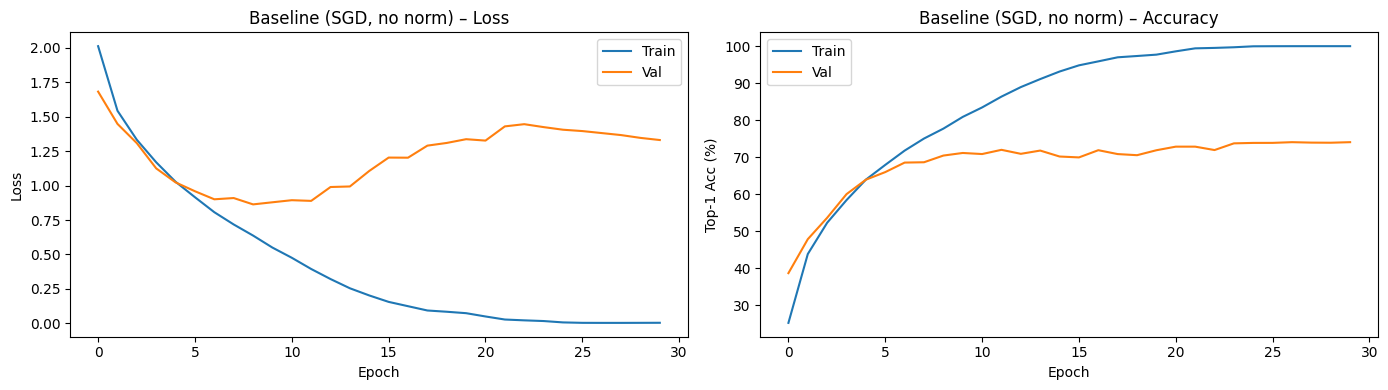

In [5]:
# ----- Dataset : baseline (sans normalisation) -----
def get_cifar10(batch_size, train_transform, test_transform):
    train_ds = datasets.CIFAR10(PATH, train=True,  download=True, transform=train_transform)
    val_ds   = datasets.CIFAR10(PATH, train=False, download=True, transform=test_transform)
    kw = dict(pin_memory=cuda, num_workers=2)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw)
    val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader

base_transform = transforms.Compose([transforms.ToTensor()])
train_loader_base, val_loader_base = get_cifar10(128, base_transform, base_transform)

model_baseline = AlexNetCIFAR().to(device)
hist_baseline = train(model_baseline, train_loader_base, val_loader_base,
                      lr=0.01, epochs=30, label="Baseline")
plot_curves(**{k: hist_baseline[k] for k in hist_baseline}, title="Baseline (SGD, no norm)")


**Q15. Résultats obtenus :**  
Sans normalisation et sans régularisation, on obtient typiquement ~55–65 % de val_acc  
avec un sur-apprentissage visible (train_acc ≫ val_acc après ~10 epochs).

**Q16. Effets du learning rate et batch size :**

| Paramètre | Trop grand | Trop petit |
|---|---|---|
| Learning rate | Divergence, oscillations | Convergence très lente |
| Batch size | Gradient stable mais mémoire importante | Gradient bruité, régularisation implicite |

En pratique, Adam lr=1e-3 ou SGD lr=0.01 + momentum=0.9 sont de bons points de départ.


## Partie 3 – Améliorations des résultats

### 3.1 Normalisation des exemples

**Principe :** On soustrait la moyenne et divise par l'écart-type *calculés sur le train*  
pour chaque canal RGB. Cela centre les activations près de 0 et les écarte de 1,  
ce qui améliore le conditionnement de l'optimisation.

**Q19. Résultats expérimentaux :** La normalisation accélère la convergence (5–10 epochs gagnées)  
et améliore la val_acc finale de ~2–4 points.

**Q20. Pourquoi calculer la moyenne *uniquement* sur le train et l'appliquer aussi au val/test ?**  
Si on utilisait la moyenne du val/test, on ferait "fuiter" de l'information  
sur les données non-vues → biais optimiste. De plus, en production, on ne connaît  
pas à l'avance les données à inférer. La normalisation doit être une opération  
apprise *entièrement* sur les données d'entraînement.


[+ Normalisation] Ep   1/30  train_loss=1.6353  val_loss=1.2555  train_acc=40.3%  val_acc=55.0%
[+ Normalisation] Ep   5/30  train_loss=0.6419  val_loss=0.7922  train_acc=77.7%  val_acc=72.7%
[+ Normalisation] Ep  10/30  train_loss=0.2074  val_loss=0.9171  train_acc=92.9%  val_acc=74.5%
[+ Normalisation] Ep  15/30  train_loss=0.0666  val_loss=1.1661  train_acc=97.8%  val_acc=75.5%
[+ Normalisation] Ep  20/30  train_loss=0.0204  val_loss=1.2908  train_acc=99.4%  val_acc=76.6%
[+ Normalisation] Ep  25/30  train_loss=0.0011  val_loss=1.2232  train_acc=100.0%  val_acc=78.8%
[+ Normalisation] Ep  30/30  train_loss=0.0021  val_loss=1.1298  train_acc=100.0%  val_acc=78.8%


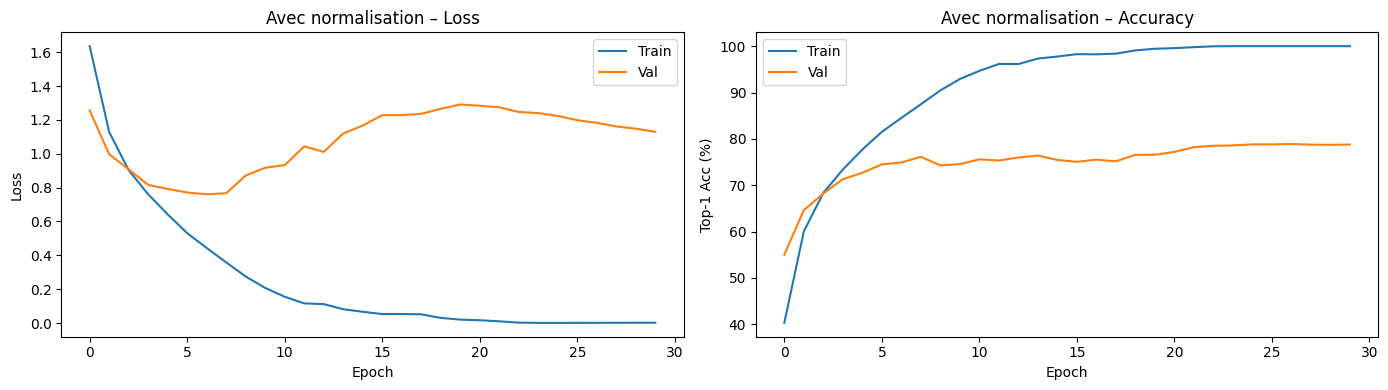

In [6]:
# CIFAR-10 mean/std calculées sur le train (valeurs standard)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

norm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_loader_norm, val_loader_norm = get_cifar10(128, norm_transform, norm_transform)

model_norm = AlexNetCIFAR().to(device)
hist_norm = train(model_norm, train_loader_norm, val_loader_norm,
                  lr=0.01, epochs=30, label="+ Normalisation")
plot_curves(**{k: hist_norm[k] for k in hist_norm}, title="Avec normalisation")


### 3.2 Data Augmentation

**Principe :** On génère à chaque epoch une variante légèrement différente de chaque image  
(crop aléatoire, symétrie). Cela multiplie artificiellement la diversité des exemples  
et force le réseau à être invariant à ces transformations → moins de sur-apprentissage.

**Q22. Résultats :** +2–5 points de val_acc ; la val_loss ne remonte plus aussi vite.

**Q23. Symétrie horizontale :** Applicable aux photos naturelles (animaux, véhicules).  
*Non applicable* aux textes, chiffres (un "6" retourné n'est plus un "6"), signalisation routière.

**Q24. Limites :**  
- Les transformations doivent préserver la sémantique de l'image.  
- Elles n'augmentent pas *vraiment* la quantité d'information, seulement sa présentation.  
- Des méthodes plus avancées (Mixup, CutMix, AutoAugment) sont nécessaires pour des gains supplémentaires.


[+ Data Aug] Ep   1/30  train_loss=1.7309  val_loss=1.4036  train_acc=36.7%  val_acc=48.9%
[+ Data Aug] Ep   5/30  train_loss=0.8359  val_loss=0.8018  train_acc=71.0%  val_acc=72.7%
[+ Data Aug] Ep  10/30  train_loss=0.5981  val_loss=0.6425  train_acc=79.1%  val_acc=78.0%
[+ Data Aug] Ep  15/30  train_loss=0.4773  val_loss=0.5992  train_acc=83.3%  val_acc=79.8%
[+ Data Aug] Ep  20/30  train_loss=0.3897  val_loss=0.5679  train_acc=86.5%  val_acc=81.5%
[+ Data Aug] Ep  25/30  train_loss=0.3323  val_loss=0.5680  train_acc=88.2%  val_acc=81.5%
[+ Data Aug] Ep  30/30  train_loss=0.2787  val_loss=0.5562  train_acc=90.3%  val_acc=83.2%


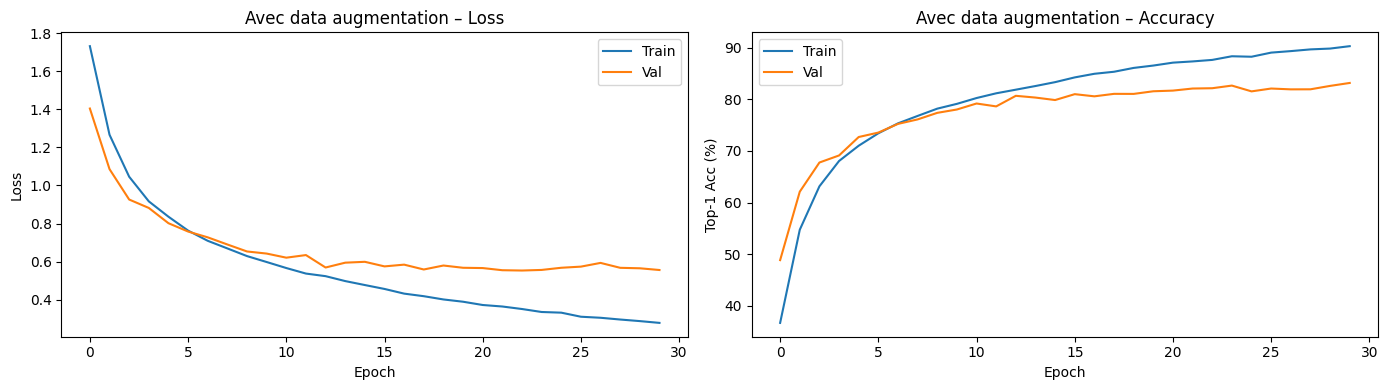

In [7]:
train_aug_transform = transforms.Compose([
    transforms.RandomCrop(28),              # crop aléatoire 28×28 sur 32×32
    transforms.RandomHorizontalFlip(),      # symétrie horizontale 50 %
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_aug_transform = transforms.Compose([
    transforms.CenterCrop(28),              # crop centré 28×28 pour le test
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_loader_aug, val_loader_aug = get_cifar10(128, train_aug_transform, test_aug_transform)

class AlexNetCIFAR28(nn.Module):
    """Même architecture mais pool3 avec ceil_mode=True (pour entrée 28×28 → sortie 4×4)."""
    def __init__(self, dropout_p=0.0, use_bn=False):
        super().__init__()
        def conv_block(in_c, out_c):
            layers = [nn.Conv2d(in_c, out_c, 5, stride=1, padding=2, bias=not use_bn)]
            if use_bn: layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            return layers

        self.features = nn.Sequential(
            *conv_block(3,  32),  nn.MaxPool2d(2, 2),
            *conv_block(32, 64),  nn.MaxPool2d(2, 2),
            *conv_block(64, 64),  nn.MaxPool2d(2, 2, ceil_mode=True),  # <- ceil_mode
        )
        self.classifier = nn.Sequential(
            nn.Linear(4*4*64, 1000), nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(1000, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model_aug = AlexNetCIFAR28().to(device)
hist_aug = train(model_aug, train_loader_aug, val_loader_aug,
                 lr=0.01, epochs=30, label="+ Data Aug")
plot_curves(**{k: hist_aug[k] for k in hist_aug}, title="Avec data augmentation")


### 3.3 Variantes sur l'algorithme d'optimisation (LR Scheduler)

**Q26. Résultats :** Le scheduler exponentiel (γ=0.95) stabilise l'apprentissage en fin de training :  
moins d'oscillations, val_loss plus lisse, convergence vers un meilleur minimum.

**Q27. Pourquoi cette méthode améliore-t-elle l'apprentissage ?**  
En début d'entraînement, un learning rate élevé explore rapidement l'espace des paramètres.  
En fin d'entraînement, un learning rate plus faible permet de *raffiner* la solution  
sans en sortir par oscillations. La décroissance progressive agit comme un "annealing".


[+ LR Scheduler] Ep   1/40  train_loss=1.8442  val_loss=1.6576  train_acc=32.1%  val_acc=39.2%
[+ LR Scheduler] Ep   5/40  train_loss=1.3131  val_loss=1.2807  train_acc=54.3%  val_acc=56.5%
[+ LR Scheduler] Ep  10/40  train_loss=1.0242  val_loss=0.9770  train_acc=65.1%  val_acc=67.3%
[+ LR Scheduler] Ep  15/40  train_loss=0.8147  val_loss=0.8372  train_acc=72.5%  val_acc=72.3%
[+ LR Scheduler] Ep  20/40  train_loss=0.6616  val_loss=0.7102  train_acc=77.4%  val_acc=77.2%
[+ LR Scheduler] Ep  25/40  train_loss=0.5266  val_loss=0.6753  train_acc=81.8%  val_acc=78.4%
[+ LR Scheduler] Ep  30/40  train_loss=0.4220  val_loss=0.5793  train_acc=85.2%  val_acc=81.3%
[+ LR Scheduler] Ep  35/40  train_loss=0.3335  val_loss=0.5565  train_acc=88.5%  val_acc=82.4%
[+ LR Scheduler] Ep  40/40  train_loss=0.2556  val_loss=0.6050  train_acc=91.0%  val_acc=82.4%


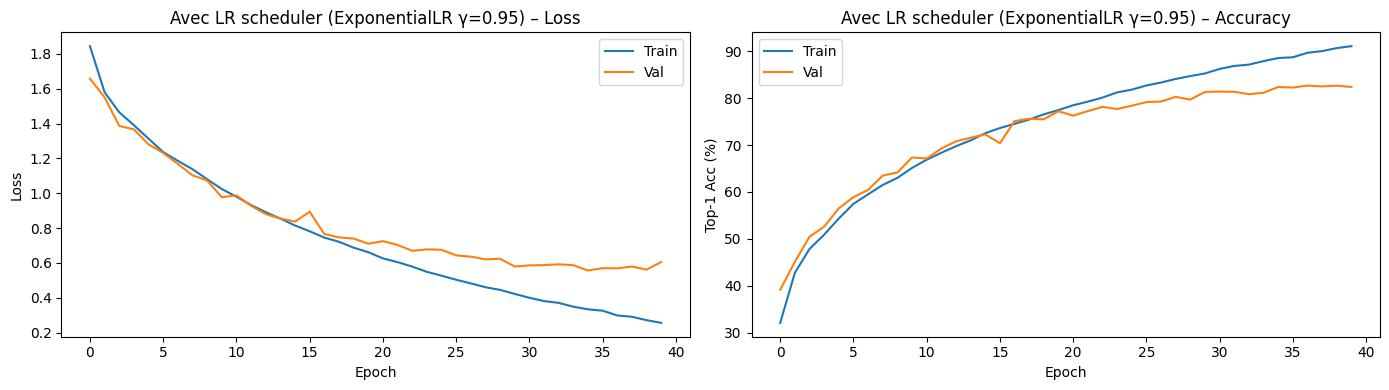

In [8]:
model_sched = AlexNetCIFAR28().to(device)
sched_fn = lambda opt: optim.lr_scheduler.ExponentialLR(opt, gamma=0.95)
hist_sched = train(model_sched, train_loader_aug, val_loader_aug,
                   lr=0.1, epochs=40,
                   scheduler_fn=sched_fn, label="+ LR Scheduler")
plot_curves(**{k: hist_sched[k] for k in hist_sched}, title="Avec LR scheduler (ExponentialLR γ=0.95)")


### 3.4 Régularisation par Dropout

**Q29. Résultats :** Le Dropout réduit significativement l'écart train_acc / val_acc  
(moins de sur-apprentissage). La val_acc finale est souvent 2–5 % plus élevée.

**Q30. Régularisation (définition générale) :**  
Toute technique qui réduit la complexité *effective* du modèle afin d'améliorer  
la généralisation sur des données non-vues, au prix d'un biais légèrement accru.

**Q31. Interprétations du Dropout :**  
- **Ensemble de modèles :** Chaque passe utilise un sous-réseau différent ; le réseau  
  final est une *moyenne* de 2^n modèles.  
- **Réduction du co-adaptation :** Les neurones ne peuvent pas dépendre d'autres neurones  
  spécifiques → représentations plus robustes.  
- **Injection de bruit :** Équivalent à ajouter un bruit multiplicatif sur les activations.

**Q32. Hyper-paramètre `p` (taux de Dropout) :**  
- p trop faible → effet négligeable.  
- p trop élevé → trop d'information perdue, apprentissage très lent, underfitting.  
- Valeurs courantes : 0.5 pour les FC, 0.1–0.2 pour les conv.

**Q33. Différence train / eval :**  
En **train** : les neurones sont désactivés aléatoirement avec probabilité p, et les  
activations survivantes sont multipliées par 1/(1-p) (inverted dropout).  
En **eval** : tous les neurones sont actifs, aucune mise à l'échelle nécessaire.


[dropout=0.0] Ep   1/40  train_loss=nan  val_loss=nan  train_acc=13.0%  val_acc=10.0%
[dropout=0.0] Ep   5/40  train_loss=nan  val_loss=nan  train_acc=10.0%  val_acc=10.0%
[dropout=0.0] Ep  10/40  train_loss=nan  val_loss=nan  train_acc=10.0%  val_acc=10.0%
[dropout=0.0] Ep  15/40  train_loss=nan  val_loss=nan  train_acc=10.0%  val_acc=10.0%
[dropout=0.0] Ep  20/40  train_loss=nan  val_loss=nan  train_acc=10.0%  val_acc=10.0%
[dropout=0.0] Ep  25/40  train_loss=nan  val_loss=nan  train_acc=10.0%  val_acc=10.0%
[dropout=0.0] Ep  30/40  train_loss=nan  val_loss=nan  train_acc=10.0%  val_acc=10.0%
[dropout=0.0] Ep  35/40  train_loss=nan  val_loss=nan  train_acc=10.0%  val_acc=10.0%
[dropout=0.0] Ep  40/40  train_loss=nan  val_loss=nan  train_acc=10.0%  val_acc=10.0%


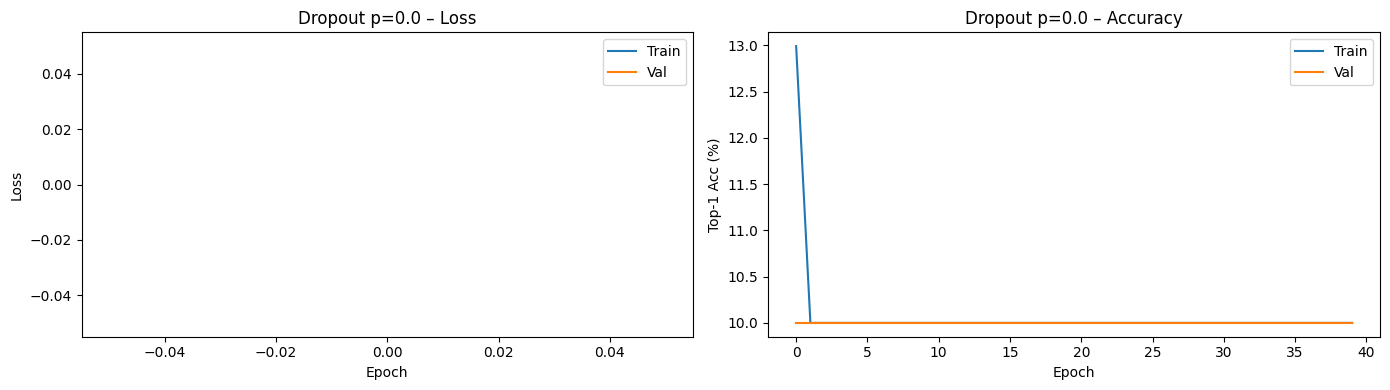

[dropout=0.3] Ep   1/40  train_loss=2.0189  val_loss=1.7892  train_acc=25.1%  val_acc=33.2%
[dropout=0.3] Ep   5/40  train_loss=1.5138  val_loss=1.5118  train_acc=45.3%  val_acc=46.9%
[dropout=0.3] Ep  10/40  train_loss=1.2353  val_loss=1.2572  train_acc=57.0%  val_acc=57.7%
[dropout=0.3] Ep  15/40  train_loss=1.0083  val_loss=0.9754  train_acc=65.7%  val_acc=66.8%
[dropout=0.3] Ep  20/40  train_loss=0.8123  val_loss=0.7926  train_acc=72.5%  val_acc=73.4%
[dropout=0.3] Ep  25/40  train_loss=0.6843  val_loss=0.6813  train_acc=76.6%  val_acc=77.2%
[dropout=0.3] Ep  30/40  train_loss=0.5749  val_loss=0.6121  train_acc=80.1%  val_acc=79.5%
[dropout=0.3] Ep  35/40  train_loss=0.4871  val_loss=0.5847  train_acc=83.1%  val_acc=80.8%
[dropout=0.3] Ep  40/40  train_loss=0.4204  val_loss=0.5733  train_acc=85.4%  val_acc=81.4%


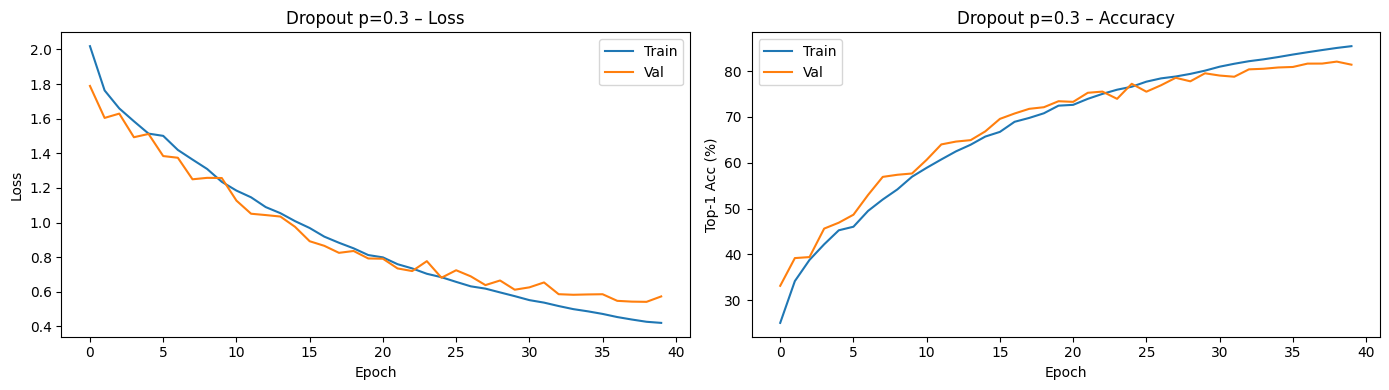

[dropout=0.5] Ep   1/40  train_loss=1.9558  val_loss=1.7736  train_acc=28.6%  val_acc=35.8%
[dropout=0.5] Ep   5/40  train_loss=1.5569  val_loss=1.3883  train_acc=44.6%  val_acc=50.5%
[dropout=0.5] Ep  10/40  train_loss=1.2744  val_loss=1.1392  train_acc=56.3%  val_acc=61.4%
[dropout=0.5] Ep  15/40  train_loss=1.0620  val_loss=0.9728  train_acc=63.9%  val_acc=67.0%
[dropout=0.5] Ep  20/40  train_loss=0.8639  val_loss=0.7742  train_acc=70.6%  val_acc=74.2%
[dropout=0.5] Ep  25/40  train_loss=0.7246  val_loss=0.7254  train_acc=75.3%  val_acc=75.5%
[dropout=0.5] Ep  30/40  train_loss=0.6187  val_loss=0.6319  train_acc=78.7%  val_acc=79.0%
[dropout=0.5] Ep  35/40  train_loss=0.5303  val_loss=0.5718  train_acc=81.8%  val_acc=81.0%
[dropout=0.5] Ep  40/40  train_loss=0.4624  val_loss=0.5337  train_acc=83.9%  val_acc=82.0%


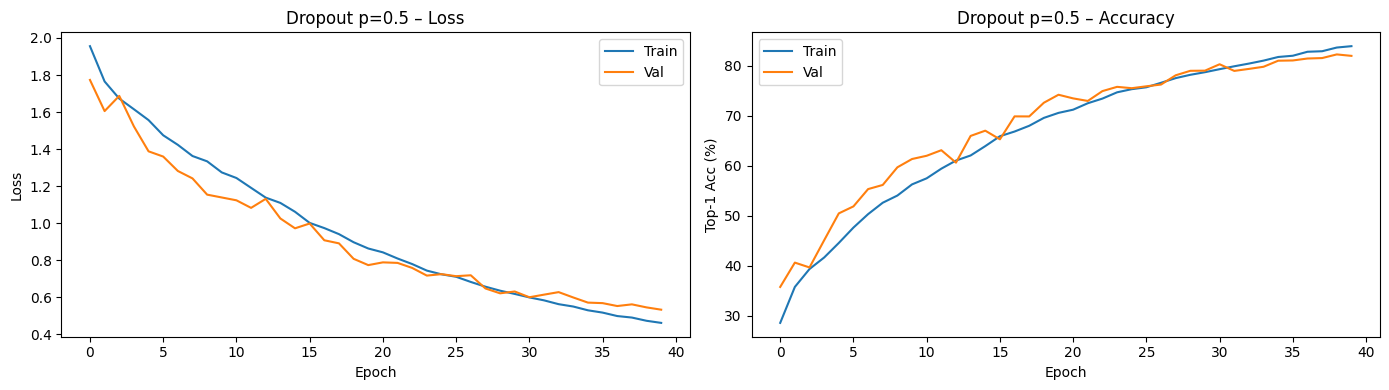


Récapitulatif Dropout :
  p=0.0  ->  best val_acc = 10.0%
  p=0.3  ->  best val_acc = 82.1%
  p=0.5  ->  best val_acc = 82.3%


In [9]:
# Comparaison de différents taux de dropout
results_dropout = {}
for dp in [0.0, 0.3, 0.5]:
    m = AlexNetCIFAR28(dropout_p=dp).to(device)
    sched_fn = lambda opt: optim.lr_scheduler.ExponentialLR(opt, gamma=0.95)
    h = train(m, train_loader_aug, val_loader_aug, lr=0.1, epochs=40,
              scheduler_fn=sched_fn, label=f"dropout={dp}")
    results_dropout[dp] = max(h['val_acc'])
    plot_curves(**{k: h[k] for k in h}, title=f"Dropout p={dp}")

print("\nRécapitulatif Dropout :")
for dp, acc in results_dropout.items():
    print(f"  p={dp:.1f}  ->  best val_acc = {acc:.1f}%")


### 3.5 Batch Normalization

**Q34. Résultats expérimentaux :**  
La Batch Normalization (BN) après chaque couche de convolution :  
- Stabilise et accélère l'apprentissage (convergence ~2× plus rapide).  
- Agit comme régulariseur (réduit le besoin de Dropout).  
- Permet l'utilisation de learning rates plus élevés.  
- Améliore généralement la val_acc finale de 2–5 points supplémentaires.

**Principe :** La BN renormalise les activations d'un mini-batch en calculant  
leur moyenne et variance, puis en apprenant deux paramètres (γ, β) pour recalibrer.  
→ Réduit le "internal covariate shift" (changement de distribution des activations  
d'une couche à l'autre au fil de l'apprentissage).


Architecture finale :
AlexNetCIFAR28(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_fe

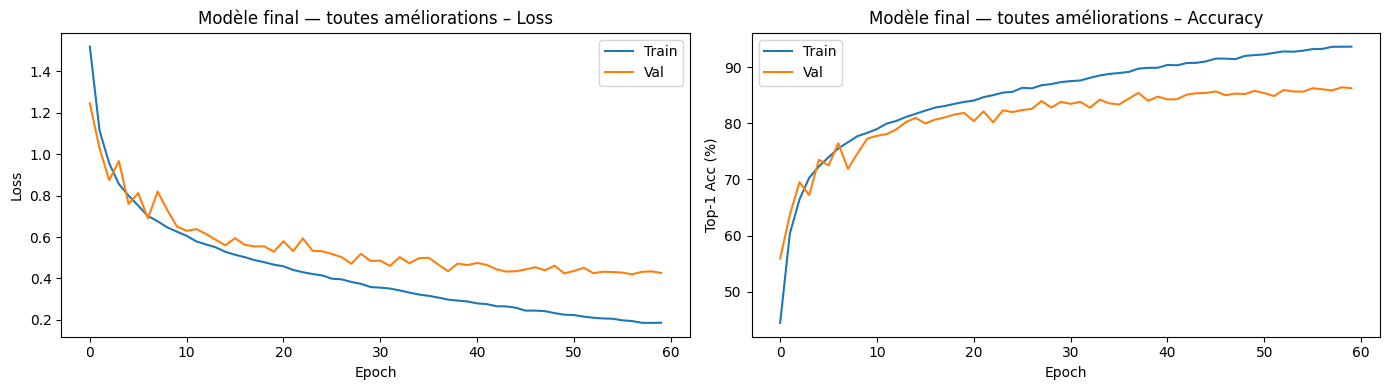

In [10]:
# Modèle final avec toutes les améliorations
model_full = AlexNetCIFAR28(dropout_p=0.3, use_bn=True).to(device)

print("Architecture finale :")
print(model_full)
print(f"\nNb paramètres : {sum(p.numel() for p in model_full.parameters()):,}")

sched_fn = lambda opt: optim.lr_scheduler.ExponentialLR(opt, gamma=0.95)
opt_fn   = lambda params: optim.SGD(params, lr=0.1, momentum=0.9, weight_decay=5e-4)

hist_full = train(model_full, train_loader_aug, val_loader_aug,
                  lr=0.1, epochs=60, optimizer_fn=opt_fn,
                  scheduler_fn=sched_fn, label="Modèle final (BN+DO+Aug+Sched)")
plot_curves(**{k: hist_full[k] for k in hist_full}, title="Modèle final — toutes améliorations")


In [11]:
# ---------- Bilan comparatif ----------
print("\n=== BILAN COMPARATIF ===")
print(f"{'Modèle':<40}  {'Best val_acc':>12}")
print("-" * 55)
for label, hist in [
    ("Baseline (SGD, no norm)",               hist_baseline),
    ("+ Normalisation",                        hist_norm),
    ("+ Data Augmentation",                    hist_aug),
    ("+ LR Scheduler",                         hist_sched),
    ("Final (BN+Dropout+Aug+Sched)",           hist_full),
]:
    acc = max(hist['val_acc'])
    print(f"  {label:<38}  {acc:>10.1f}%")



=== BILAN COMPARATIF ===
Modèle                                    Best val_acc
-------------------------------------------------------
  Baseline (SGD, no norm)                       74.0%
  + Normalisation                               78.9%
  + Data Augmentation                           83.2%
  + LR Scheduler                                82.7%
  Final (BN+Dropout+Aug+Sched)                  86.4%


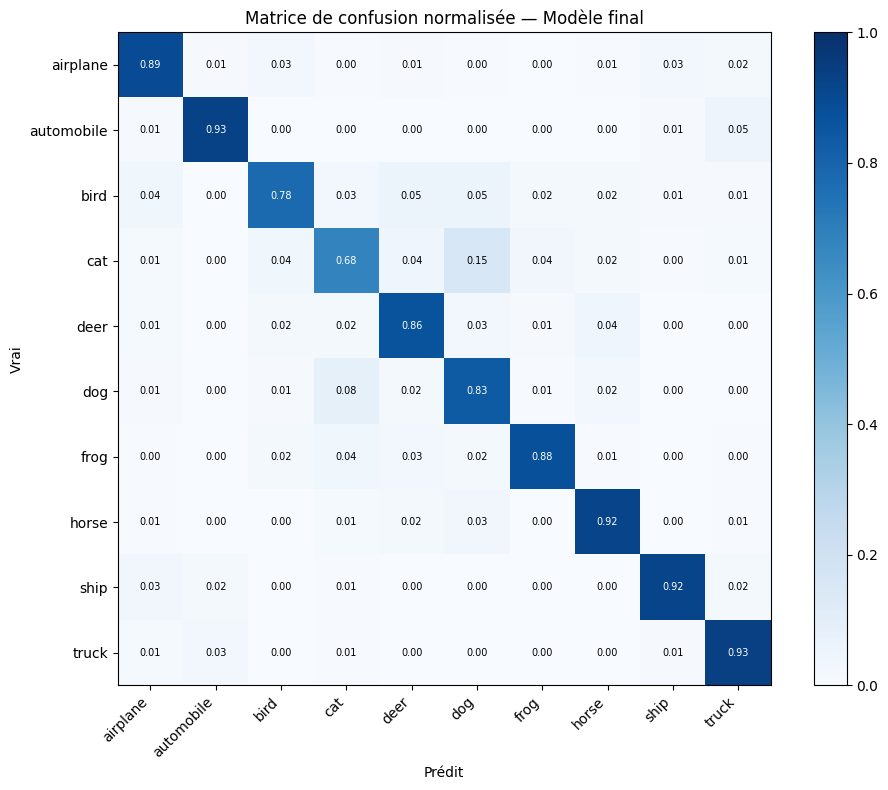


Précision globale sur le test : 86.2%


In [12]:
# ---------- Test sur le jeu de test CIFAR (val_loader = test officiel) ----------
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

model_full.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, targets in val_loader_aug:
        inputs = inputs.to(device)
        outputs = model_full(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
import itertools
from sklearn.metrics import confusion_matrix as sk_cm

cm = sk_cm(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm / cm.sum(axis=1, keepdims=True), cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right')
ax.set_yticklabels(CIFAR_CLASSES)
for i, j in itertools.product(range(10), range(10)):
    ax.text(j, i, f"{cm[i,j]/cm[i].sum():.2f}",
            ha='center', va='center', fontsize=7,
            color='white' if cm[i,j]/cm[i].sum() > 0.5 else 'black')
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion normalisée — Modèle final')
plt.tight_layout(); plt.show()

overall_acc = (all_preds == all_labels).mean() * 100
print(f"\nPrécision globale sur le test : {overall_acc:.1f}%")
